# AstroBurst v2 API — hands-on demo

Exercises every endpoint added in issues [#2–#9](https://github.com/leejjoon/AstroBurst/issues?q=is%3Aissue+is%3Aclosed):
session/image lifecycle, WCS coordinate transforms, inspection, cutout, block-average
rebinning, pixel point-queries, region-scoped stats, and region-scoped histograms.

Built directly from `SERVER_TESTING.md` §11 onward — that file is the
authoritative reference if anything here and the server disagree.

**Note:** v2 has no render/PNG endpoint of its own yet (deferred — see the plan doc).
Since `POST /v2/sessions` reuses v1's session store verbatim, this notebook uses v1's
`POST /sessions/:sid/image/stf` to render PNGs of v2-created image refs for visual
sanity-checking.

**Dependencies:** `requests`, `matplotlib`, `pillow`. Run this notebook with e.g.
`uv run --with requests --with matplotlib --with pillow --with jupyter jupyter lab`
from the repo root.


In [1]:
import json
import subprocess
import time
from io import BytesIO
from pathlib import Path

import matplotlib.pyplot as plt
import requests
from PIL import Image

BASE = "http://localhost:8080"

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "examples":  # running from agent/examples/
    REPO_ROOT = REPO_ROOT.parent.parent
assert (REPO_ROOT / "Cargo.toml").is_file(), f"couldn't find repo root from {Path.cwd()}"

FITS_PATH = str((REPO_ROOT / "exampleFits/sample-data/656nmos.fits").resolve())
NO_WCS_CANDIDATE_PATH = str((REPO_ROOT / "tests/fixtures/fits_compressed/rice_i16_default_tile.fits").resolve())

print("repo root:", REPO_ROOT)
print("fits fixture:", FITS_PATH)


repo root: /home/jjlee/fits_agent/AstroBurst
fits fixture: /home/jjlee/fits_agent/AstroBurst/exampleFits/sample-data/656nmos.fits


In [2]:
def v2(method, path, **kw):
    return requests.request(method, f"{BASE}/v2{path}", **kw)

def v1(method, path, **kw):
    return requests.request(method, f"{BASE}{path}", **kw)

def pj(label, resp, max_chars=2000):
    """Pretty-print a JSON response (truncated) and return it for further use."""
    print(f"--- {label}  [{resp.status_code}] ---")
    try:
        body = json.dumps(resp.json(), indent=2)
        print(body[:max_chars] + (" ...(truncated)" if len(body) > max_chars else ""))
    except ValueError:
        print(resp.text[:500])
    print()
    return resp

def show_png(resp, title):
    assert resp.headers.get("content-type", "").startswith("image/"), resp.text[:300]
    img = Image.open(BytesIO(resp.content))
    plt.figure(figsize=(5, 5))
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()


## 1. Start (or connect to) the server

In [3]:
server_proc = None
try:
    r = requests.get(f"{BASE}/health", timeout=1)
    print("Found a server already running:", r.json())
except requests.exceptions.RequestException:
    print("No server reachable at", BASE, "-- starting one (this may take a moment)...")
    log_path = "/tmp/astroburst-server-notebook.log"
    log = open(log_path, "w")
    server_proc = subprocess.Popen(
        [
            "cargo", "run", "--bin", "astroburst-server",
            "--no-default-features", "--features", "server,astrometry-net,asdf-full,vizier",
        ],
        cwd=str(REPO_ROOT),
        stdout=log, stderr=subprocess.STDOUT,
    )
    for _ in range(180):
        try:
            r = requests.get(f"{BASE}/health", timeout=1)
            if r.ok:
                print("Server is up:", r.json())
                break
        except requests.exceptions.RequestException:
            time.sleep(1)
    else:
        raise RuntimeError(f"Server did not become healthy in time -- check {log_path}")


No server reachable at http://localhost:8080 -- starting one (this may take a moment)...
Server is up: {'sessions_active': 0, 'sessions_total': 0, 'status': 'ok', 'version': '0.5.3'}


## 2. Session & image lifecycle (issue #2)

Create a session, open a real FITS file, list/inspect refs, and (if the file has more
than one data HDU) switch HDUs into a second ref.


In [4]:
sid = v2("POST", "/sessions").json()["session_id"]
print("session:", sid)

open_resp = pj("open", v2("POST", f"/sessions/{sid}/open", json={"path": FITS_PATH})).json()
img0 = open_resp["ref"]
dims = open_resp["dims"]
wcs_present = open_resp["wcs_present"]
print(f"ref={img0} dims={dims} wcs_present={wcs_present} median={open_resp['stats']['median']:.4f}")

pj("images", v2("GET", f"/sessions/{sid}/images"))
pj("status", v2("GET", f"/sessions/{sid}"))


session: b7c637cf-5f5a-49c4-a3e8-085522549879
--- open  [200] ---
{
  "active_ref": "img_0",
  "dims": [
    1600,
    1600
  ],
  "extname": null,
  "hdu": null,
  "header": {
    "ALLG-MAX": "0.000000E0",
    "ALLG-MIN": "0.000000E0",
    "ASTR_I": "$RCSfile: image_type.cl,v $ $Revision: 1.1 $",
    "ATODCORR": "COMPLETE",
    "ATODFILE": "uref$dbu1405iu.r1h",
    "ATODGAIN": "7.000000000000",
    "ATODSAT": "15",
    "BACKGRND": "42.37756",
    "BADPIXEL": "0",
    "BIASCORR": "COMPLETE",
    "BIASDFIL": "uref$fcb1503du.b2h",
    "BIASEVEN": "311.3347",
    "BIASFILE": "uref$fcb1503du.r2h",
    "BIASODD": "311.2736",
    "BITPIX": "-32",
    "BLEVCORR": "COMPLETE",
    "BLEVDFIL": "ucal$u2lx0501t.q1h",
    "BLEVFILE": "ucal$u2lx0501t.x0h",
    "BSCALE": "1.0E0",
    "BZERO": "0.0E0",
    "CALIBDEF": "80081",
    "CD1_1": "1.878013E-5",
    "CD1_2": "-2.031193E-5",
    "CD2_1": "-2.029358E-5",
    "CD2_2": "-1.879711E-5",
    "CDBSFILE": "NO",
    "COMPTAB": "mtab$m4i1217km.tmc",
   

<Response [200]>

In [5]:
structure = v2("GET", f"/sessions/{sid}/structure").json()
n_data_hdus = sum(1 for h in structure["hdus"] if h.get("has_data"))
print(f"{n_data_hdus} data HDU(s) in this file")

if n_data_hdus > 1:
    pj("hdu switch -> new ref", v2("POST", f"/sessions/{sid}/hdu", json={"hdu": 1}))
    pj("images after hdu switch (both refs still present)", v2("GET", f"/sessions/{sid}/images"))
else:
    print("Only one data HDU -- skipping the hdu-switch demo for this fixture.")

pj("keepalive (no-op)", v2("POST", f"/sessions/{sid}/keepalive"))


1 data HDU(s) in this file
Only one data HDU -- skipping the hdu-switch demo for this fixture.
--- keepalive (no-op)  [200] ---
{
  "session_id": "b7c637cf-5f5a-49c4-a3e8-085522549879",
  "status": "ok"
}



<Response [200]>

## 3. Visual sanity check via v1's render endpoint

`image_ref`s are literal `ImageCache` slot keys, so v1's `image/stf` auto-render works
directly against them.


stf params: {"highlight":1.0,"midtone":0.07133587668436113,"shadow":0.0}


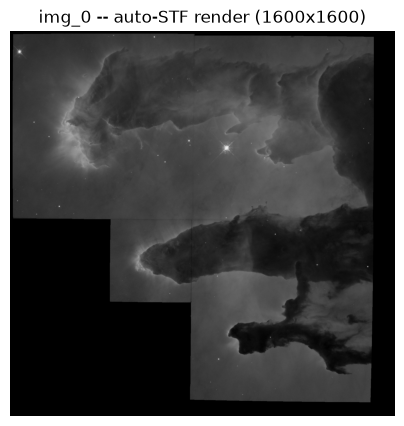

In [6]:
r = v1("POST", f"/sessions/{sid}/image/stf", json={"slot": img0})
print("stf params:", r.headers.get("x-stf-params"))
show_png(r, f"{img0} -- auto-STF render ({dims[0]}x{dims[1]})")


## 4. Inspection -- structure / header / WCS summary (issue #4)

In [7]:
pj("structure", v2("GET", f"/sessions/{sid}/structure", params={"ref": img0}))
pj("header (explicit subset)", v2("GET", f"/sessions/{sid}/header", params={"ref": img0, "keys": "CTYPE1,CRVAL1,CRVAL2,NAXIS1,NAXIS2"}))
pj("header (glob CD*_*)", v2("GET", f"/sessions/{sid}/header", params={"ref": img0, "keys": "CD*_*"}))
wcs_summary = pj("wcs summary", v2("GET", f"/sessions/{sid}/wcs", params={"ref": img0})).json()


--- structure  [200] ---
{
  "count": 2,
  "hdus": [
    {
      "bitpix": -32,
      "dtype": "float32",
      "extname": null,
      "extver": null,
      "has_data": true,
      "index": 0,
      "naxis": 2,
      "shape": [
        1600,
        1600
      ]
    },
    {
      "bitpix": 8,
      "dtype": "uint8",
      "extname": "656nmos_cvt.tab",
      "extver": null,
      "has_data": false,
      "index": 1,
      "naxis": 2,
      "shape": [
        1,
        796
      ]
    }
  ],
  "ref": "img_0"
}

--- header (explicit subset)  [200] ---
{
  "cards": {
    "CRVAL1": {
      "value": "274.71149247724"
    },
    "CRVAL2": {
      "value": "-13.816384007184"
    },
    "CTYPE1": {
      "value": "RA---TAN"
    },
    "NAXIS1": {
      "value": "1600"
    },
    "NAXIS2": {
      "value": "1600"
    }
  },
  "count": 5,
  "ref": "img_0"
}

--- header (glob CD*_*)  [200] ---
{
  "cards": {
    "CD1_1": {
      "value": "1.878013E-5"
    },
    "CD1_2": {
      "value": "-2.031

## 5. WCS coordinate transforms (issue #3)

In [8]:
cx, cy = dims[0] // 2, dims[1] // 2
sample_px = [[3, 3], [100, 100], [cx, cy]]

if wcs_present:
    r = pj("pix2sky", v2("POST", f"/sessions/{sid}/wcs/pix2sky", json={"ref": img0, "points": sample_px}))
    sky_points = [[p["ra"], p["dec"]] for p in r.json()["results"]]

    r2 = pj("sky2pix (round trip)", v2("POST", f"/sessions/{sid}/wcs/sky2pix", json={"ref": img0, "points": sky_points}))
    for (x0, y0), res in zip(sample_px, r2.json()["results"]):
        err = abs(res["x"] - x0) + abs(res["y"] - y0)
        print(f"  ({x0},{y0}) -> round-trip ({res['x']:.4f},{res['y']:.4f})  |err|={err:.2e}")
    print()

    pj("separation (sky)", v2("POST", f"/sessions/{sid}/wcs/separation",
                              json={"type": "sky", "a": sky_points[0], "b": sky_points[1]}))
    pj("separation (pixel, resolved via WCS)", v2("POST", f"/sessions/{sid}/wcs/separation",
                              json={"type": "pixel", "ref": img0, "a": [3, 3], "b": [3, 4]}))
else:
    print("This fixture has no WCS -- skipping pix2sky/sky2pix/pixel-separation "
          "(see the error-handling tour at the end for the wcs_required behavior).")
    pj("separation (sky, no WCS needed either way)",
       v2("POST", f"/sessions/{sid}/wcs/separation", json={"type": "sky", "a": [150.0, 2.0], "b": [150.0, 3.0]}))


--- pix2sky  [200] ---
{
  "count": 3,
  "ref": "img_0",
  "results": [
    {
      "dec": -13.80125324476528,
      "on_image": true,
      "ra": 274.71229450947044,
      "x": 3.0,
      "y": 3.0
    },
    {
      "dec": -13.805045041940176,
      "on_image": true,
      "ra": 274.71214151812984,
      "x": 100.0,
      "y": 100.0
    },
    {
      "dec": -13.832408524806464,
      "on_image": true,
      "ra": 274.71103730925734,
      "x": 800.0,
      "y": 800.0
    }
  ]
}

--- sky2pix (round trip)  [200] ---
{
  "count": 3,
  "ref": "img_0",
  "results": [
    {
      "dec": -13.80125324476528,
      "on_image": true,
      "ra": 274.71229450947044,
      "x": 3.362839012758286,
      "y": 2.981322361425157
    },
    {
      "dec": -13.805045041940176,
      "on_image": true,
      "ra": 274.71214151812984,
      "x": 100.27191088281853,
      "y": 99.98488545213218
    },
    {
      "dec": -13.832408524806464,
      "on_image": true,
      "ra": 274.71103730925734,
      "x

## 6. Cutout -- region crop into a derived ref (issue #5)

A pixel-region cutout, a sky-region cutout (if WCS is present), and a deliberate
partial-overlap request straddling the frame edge.


--- cutout (pixel, centered)  [200] ---
{
  "active_ref": "cutout_1",
  "dims": [
    200,
    200
  ],
  "extname": null,
  "fraction_on_image": 1.0,
  "hdu": null,
  "header": {
    "ALLG-MAX": "0.000000E0",
    "ALLG-MIN": "0.000000E0",
    "ASTR_I": "$RCSfile: image_type.cl,v $ $Revision: 1.1 $",
    "ATODCORR": "COMPLETE",
    "ATODFILE": "uref$dbu1405iu.r1h",
    "ATODGAIN": "7.000000000000",
    "ATODSAT": "15",
    "BACKGRND": "42.37756",
    "BADPIXEL": "0",
    "BIASCORR": "COMPLETE",
    "BIASDFIL": "uref$fcb1503du.b2h",
    "BIASEVEN": "311.3347",
    "BIASFILE": "uref$fcb1503du.r2h",
    "BIASODD": "311.2736",
    "BITPIX": "-32",
    "BLEVCORR": "COMPLETE",
    "BLEVDFIL": "ucal$u2lx0501t.q1h",
    "BLEVFILE": "ucal$u2lx0501t.x0h",
    "BSCALE": "1.0E0",
    "BZERO": "0.0E0",
    "CALIBDEF": "80081",
    "CD1_1": "1.878013E-5",
    "CD1_2": "-2.031193E-5",
    "CD2_1": "-2.029358E-5",
    "CD2_2": "-1.879711E-5",
    "CDBSFILE": "NO",
    "COMPTAB": "mtab$m4i1217km.tmc",


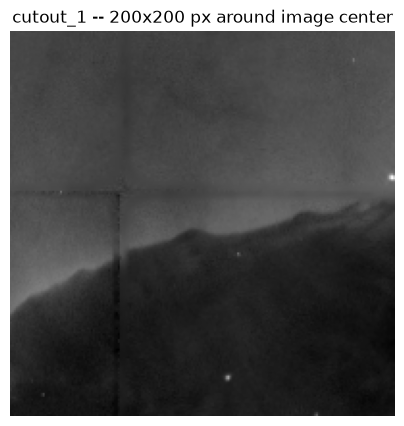

In [9]:
half = 100
r = pj("cutout (pixel, centered)", v2("POST", f"/sessions/{sid}/cutout", json={
    "ref": img0,
    "region": {"type": "pixel", "x": cx - half, "y": cy - half, "width": 2 * half, "height": 2 * half}
}))
cutout_ref = r.json()["ref"]
show_png(v1("POST", f"/sessions/{sid}/image/stf", json={"slot": cutout_ref}),
         f"{cutout_ref} -- {2*half}x{2*half} px around image center")


--- cutout (sky, 2'x2')  [200] ---
{
  "active_ref": "cutout_2",
  "dims": [
    1205,
    1205
  ],
  "extname": null,
  "fraction_on_image": 1.0,
  "hdu": null,
  "header": {
    "ALLG-MAX": "0.000000E0",
    "ALLG-MIN": "0.000000E0",
    "ASTR_I": "$RCSfile: image_type.cl,v $ $Revision: 1.1 $",
    "ATODCORR": "COMPLETE",
    "ATODFILE": "uref$dbu1405iu.r1h",
    "ATODGAIN": "7.000000000000",
    "ATODSAT": "15",
    "BACKGRND": "42.37756",
    "BADPIXEL": "0",
    "BIASCORR": "COMPLETE",
    "BIASDFIL": "uref$fcb1503du.b2h",
    "BIASEVEN": "311.3347",
    "BIASFILE": "uref$fcb1503du.r2h",
    "BIASODD": "311.2736",
    "BITPIX": "-32",
    "BLEVCORR": "COMPLETE",
    "BLEVDFIL": "ucal$u2lx0501t.q1h",
    "BLEVFILE": "ucal$u2lx0501t.x0h",
    "BSCALE": "1.0E0",
    "BZERO": "0.0E0",
    "CALIBDEF": "80081",
    "CD1_1": "1.878013E-5",
    "CD1_2": "-2.031193E-5",
    "CD2_1": "-2.029358E-5",
    "CD2_2": "-1.879711E-5",
    "CDBSFILE": "NO",
    "COMPTAB": "mtab$m4i1217km.tmc",
   

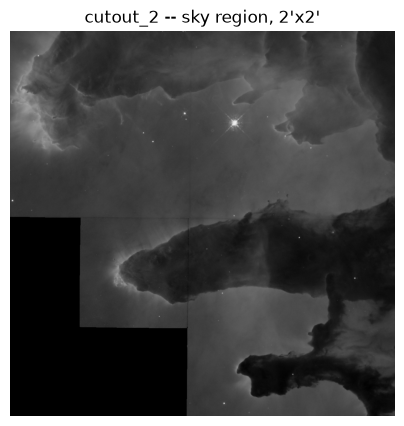

In [10]:
if wcs_present:
    center_sky = v2("POST", f"/sessions/{sid}/wcs/pix2sky", json={"ref": img0, "points": [[cx, cy]]}).json()["results"][0]
    r = pj("cutout (sky, 2'x2')", v2("POST", f"/sessions/{sid}/cutout", json={
        "ref": img0,
        "region": {"type": "sky", "ra": center_sky["ra"], "dec": center_sky["dec"], "size_arcmin": [2.0, 2.0]}
    }))
    sky_cutout_ref = r.json()["ref"]
    show_png(v1("POST", f"/sessions/{sid}/image/stf", json={"slot": sky_cutout_ref}),
             f"{sky_cutout_ref} -- sky region, 2'x2'")
else:
    print("No WCS on this fixture -- skipping the sky-region cutout.")


In [11]:
# Deliberately straddle the top-right corner: only part of the requested box is on-image.
edge_x, edge_y = dims[0] - 50, dims[1] - 50
r = pj("cutout (partial overlap)", v2("POST", f"/sessions/{sid}/cutout", json={
    "ref": img0,
    "region": {"type": "pixel", "x": edge_x, "y": edge_y, "width": 100, "height": 100}
}))
print("fraction_on_image:", r.json()["fraction_on_image"], "(expected 0.25 -- a 50x50 corner of a 100x100 request)")


--- cutout (partial overlap)  [200] ---
{
  "active_ref": "cutout_3",
  "dims": [
    100,
    100
  ],
  "extname": null,
  "fraction_on_image": 0.25,
  "hdu": null,
  "header": {
    "ALLG-MAX": "0.000000E0",
    "ALLG-MIN": "0.000000E0",
    "ASTR_I": "$RCSfile: image_type.cl,v $ $Revision: 1.1 $",
    "ATODCORR": "COMPLETE",
    "ATODFILE": "uref$dbu1405iu.r1h",
    "ATODGAIN": "7.000000000000",
    "ATODSAT": "15",
    "BACKGRND": "42.37756",
    "BADPIXEL": "0",
    "BIASCORR": "COMPLETE",
    "BIASDFIL": "uref$fcb1503du.b2h",
    "BIASEVEN": "311.3347",
    "BIASFILE": "uref$fcb1503du.r2h",
    "BIASODD": "311.2736",
    "BITPIX": "-32",
    "BLEVCORR": "COMPLETE",
    "BLEVDFIL": "ucal$u2lx0501t.q1h",
    "BLEVFILE": "ucal$u2lx0501t.x0h",
    "BSCALE": "1.0E0",
    "BZERO": "0.0E0",
    "CALIBDEF": "80081",
    "CD1_1": "1.878013E-5",
    "CD1_2": "-2.031193E-5",
    "CD2_1": "-2.029358E-5",
    "CD2_2": "-1.879711E-5",
    "CDBSFILE": "NO",
    "COMPTAB": "mtab$m4i1217km.tmc",

## 7. Block-average rebinning (issue #6)

--- bin factor=4  [200] ---
{
  "active_ref": "bin_4",
  "dims": [
    400,
    400
  ],
  "factor": 4,
  "from_ref": "img_0",
  "method": "mean",
  "ref": "bin_4",
  "stats": {
    "mad": 19.684654235839844,
    "max": 2045.3994140625,
    "mean": 103.14919553069201,
    "median": 100.90079498291016,
    "min": 4.788290023803711,
    "sigma": 29.184468370056152,
    "valid_count": 115285
  },
  "wcs_present": false
}



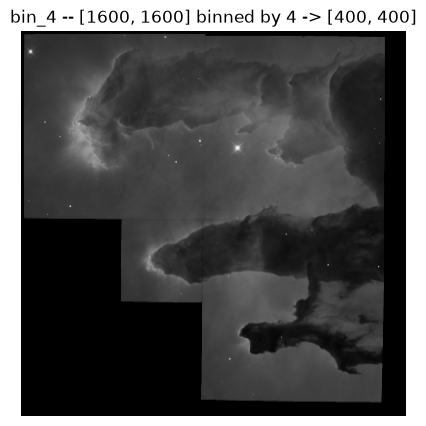

--- bin method=sum (unsupported -- expect 400 bad_request)  [400] ---
{
  "error": {
    "code": "bad_request",
    "hint": "sum-binning is inexact on edge blocks when dims aren't divisible by factor; use method \"mean\"",
    "message": "unsupported bin method \"sum\"; only \"mean\" is supported"
  },
  "success": false
}



<Response [400]>

In [12]:
r = pj("bin factor=4", v2("POST", f"/sessions/{sid}/bin", json={"ref": img0, "factor": 4, "method": "mean"}))
bin_ref = r.json()["ref"]
show_png(v1("POST", f"/sessions/{sid}/image/stf", json={"slot": bin_ref}),
         f"{bin_ref} -- {dims} binned by 4 -> {r.json()['dims']}")

pj("bin method=sum (unsupported -- expect 400 bad_request)",
   v2("POST", f"/sessions/{sid}/bin", json={"ref": img0, "factor": 4, "method": "sum"}))


## 8. Pixel point-query (issue #7)

Value + neighborhood stats + sky coordinate at a point; the box clips at image edges.


In [13]:
pj("pixel (image center)", v2("POST", f"/sessions/{sid}/pixel", json={"ref": img0, "x": cx, "y": cy, "box": 5}))
pj("pixel (near top-left corner -- box gets clipped)",
   v2("POST", f"/sessions/{sid}/pixel", json={"ref": img0, "x": 1, "y": 1, "box": 5}))


--- pixel (image center)  [200] ---
{
  "box": 5,
  "neighborhood": {
    "max": 144.86712646484375,
    "mean": 134.7809210205078,
    "min": 121.49006652832031,
    "n_nan": 0,
    "n_pixels": 25
  },
  "ref": "img_0",
  "sky": {
    "dec": -13.832408524806464,
    "ra": 274.71103730925734
  },
  "value": 135.80154418945312,
  "x": 800.0,
  "y": 800.0
}

--- pixel (near top-left corner -- box gets clipped)  [200] ---
{
  "box": 5,
  "neighborhood": {
    "max": 0.0,
    "mean": 0.0,
    "min": 0.0,
    "n_nan": 0,
    "n_pixels": 16
  },
  "ref": "img_0",
  "sky": {
    "dec": -13.801175063380516,
    "ra": 274.71229766387864
  },
  "value": 0.0,
  "x": 1.0,
  "y": 1.0
}



<Response [200]>

## 9. Region-scoped stats (issue #8)

In [14]:
pj("stats (full frame)", v2("POST", f"/sessions/{sid}/stats", json={"ref": img0}))

pj("stats (region + sigma-clip + percentiles)", v2("POST", f"/sessions/{sid}/stats", json={
    "ref": img0,
    "region": {"type": "pixel", "x": cx - 50, "y": cy - 50, "width": 100, "height": 100},
    "sigma_clip": {"sigma": 3.0, "maxiters": 5},
    "percentiles": [16, 50, 84],
}))

oob_region = {"type": "pixel", "x": dims[0] - 10, "y": dims[1] - 10, "width": 100, "height": 100}
pj("stats (out-of-bounds region -- expect 400 region_out_of_bounds)",
   v2("POST", f"/sessions/{sid}/stats", json={"ref": img0, "region": oob_region}))
pj("stats (same region, clip: true -- clamps instead of erroring)",
   v2("POST", f"/sessions/{sid}/stats", json={"ref": img0, "region": {**oob_region, "clip": True}}))


--- stats (full frame)  [200] ---
{
  "mad": 19.541526794433594,
  "max": 3194.122802734375,
  "mean": 103.68590511564639,
  "median": 100.97291946411133,
  "min": 21.772214889526367,
  "n_nan": 0,
  "ref": "img_0",
  "region": {
    "clipped": false,
    "height": 1600,
    "width": 1600,
    "x": 0,
    "y": 0
  },
  "sigma": 28.972267625427243,
  "valid_count": 1835012
}

--- stats (region + sigma-clip + percentiles)  [200] ---
{
  "clipped": {
    "mean": 100.85623979568481,
    "median": 106.17181777954102,
    "n_rejected": 0,
    "std": 40.369981352233886
  },
  "mad": 27.22917938232422,
  "max": 164.4508056640625,
  "mean": 100.85623979568481,
  "median": 106.17181777954102,
  "min": 39.79708480834961,
  "n_nan": 0,
  "percentiles": [
    {
      "percentile": 16.0,
      "value": 67.2593765258789
    },
    {
      "percentile": 50.0,
      "value": 106.17420196533203
    },
    {
      "percentile": 84.0,
      "value": 132.28314208984375
    }
  ],
  "ref": "img_0",
  "regio

<Response [200]>

## 10. Region-scoped histogram (issue #9)

In [ ]:
def plot_hist(h, title):
    if "bin_edges" not in h:
        print(f"(skipping plot -- response wasn't a histogram: {h})")
        return
    edges = h["bin_edges"]
    centers = [(edges[i] + edges[i + 1]) / 2 for i in range(len(edges) - 1)]
    width = edges[1] - edges[0] if len(edges) > 1 else 1
    plt.figure(figsize=(8, 4))
    plt.bar(centers, h["bins"], width=width)
    plt.title(title)
    plt.xlabel("pixel value")
    plt.ylabel("ln(1+count)" if h.get("log_counts") else "count")
    plt.show()

h1 = pj("histogram (full frame, auto-range)", v2("POST", f"/sessions/{sid}/histogram", json={"ref": img0})).json()
plot_hist(h1, f"full-frame histogram (auto-range, mode~{h1.get('mode')})")

h2 = pj("histogram (region, log_counts)", v2("POST", f"/sessions/{sid}/histogram", json={
    "ref": img0,
    "region": {"type": "pixel", "x": cx - 50, "y": cy - 50, "width": 100, "height": 100},
    "bins": 60,
    "log_counts": True,
})).json()
plot_hist(h2, "region histogram, log(1+count)")

pj("histogram render_png (not implemented -- expect 400)",
   v2("POST", f"/sessions/{sid}/histogram", json={"ref": img0, "render_png": True}))


## 11. Error-handling tour: a fixture with no usable WCS

Opens a second session against a file astropy reports as having no primary-HDU WCS
keywords, to exercise the `200 {"present": false}` / `400 wcs_required` contract.


In [ ]:
sid2 = v2("POST", "/sessions").json()["session_id"]
try:
    open2 = pj("open (candidate no-WCS fixture)",
               v2("POST", f"/sessions/{sid2}/open", json={"path": NO_WCS_CANDIDATE_PATH})).json()
    wcs2 = open2.get("wcs_present")
    pj("GET /wcs", v2("GET", f"/sessions/{sid2}/wcs"))
    if wcs2 is False:
        pj("pix2sky on a WCS-less image (expect 400 wcs_required)",
           v2("POST", f"/sessions/{sid2}/wcs/pix2sky", json={"points": [[1, 1]]}))
    else:
        print("This fixture actually has a WCS (e.g. in its image HDU) -- "
              "swap in a different file to see the wcs_required error.")
except Exception as e:
    print(f"Couldn't open the no-WCS candidate fixture ({e}) -- "
          "swap NO_WCS_CANDIDATE_PATH for any FITS file without a WCS header.")


## 12. Cleanup

In [ ]:
for s in (sid, sid2):
    r = v2("DELETE", f"/sessions/{s}")
    r2 = v2("GET", f"/sessions/{s}")
    print(f"{s}: delete -> {r.status_code}, subsequent GET -> {r2.status_code} (expect 404)")

if server_proc is not None:
    print("Stopping the server this notebook started...")
    server_proc.terminate()
    try:
        server_proc.wait(timeout=10)
    except subprocess.TimeoutExpired:
        server_proc.kill()
    print("Stopped.")
else:
    print("Leaving the externally-started server running.")
